# <p style="text-align: center;"> MÓDULO 4 - EXPLORATORY DATA ANALYTICS </p>
## Aula 3

### <span style="color: blue;"> * **Exercicio 1, PARTE 1**</span>


**Passo 1** - Importar os dados do ficheiro Carros3 para uma DataFrame chamada Carros3 e apagar as colunas criadas via transformações das variáveis originais.

In [1]:
import pandas as pd
import numpy as np
Carros3 = pd.read_csv('Carros3.csv')
colunas_para_remover = ['length_min_max', 'width_std', 'height_log', 'price_decile']
Carros3.drop(columns=colunas_para_remover, inplace=True, errors='ignore')

Carros3.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-size,horsepower,price
0,volkswagen,gas,std,four,sedan,fwd,front,97.3,171.7,65.5,55.7,2300,109,100.0,9995.0
1,honda,gas,std,two,sedan,fwd,front,96.5,169.1,66.0,51.0,2293,110,100.0,10345.0
2,bmw,gas,std,two,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,108,101.0,16430.0
3,mazda,gas,std,two,hatchback,rwd,front,95.3,169.0,65.7,49.6,2380,70,101.0,11845.0
4,honda,gas,std,four,sedan,fwd,front,96.5,175.4,65.2,54.1,2465,110,101.0,12945.0


**Passo 2** - Analisar as variáveis quantitativas e calcula o número de outliers, segundo IQR, que cada uma tem.

In [2]:
quantitativas = Carros3.select_dtypes(include=[np.number]).columns

outliers_iqr_contagem = {}

for col in quantitativas:
    Q1 = Carros3[col].quantile(0.25)
    Q3 = Carros3[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = Carros3[(Carros3[col] < limite_inferior) | (Carros3[col] > limite_superior)]
    outliers_iqr_contagem[col] = len(outliers)

print("Número de outliers por variável (IQR):")
print(outliers_iqr_contagem)

Número de outliers por variável (IQR):
{'wheel-base': 3, 'length': 1, 'width': 9, 'height': 0, 'curb-weight': 0, 'engine-size': 10, 'horsepower': 5, 'price': 14}


**Passo 3** - Considerar a variável quantitativa com menor número de outliers do passo anterior e eliminar os registros classificados como outliers.

In [13]:
var_menor_outlier = 'length' 

Q1 = Carros3[var_menor_outlier].quantile(0.25)
Q3 = Carros3[var_menor_outlier].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

Carros3 = Carros3[(Carros3[var_menor_outlier] >= limite_inf) & (Carros3[var_menor_outlier] <= limite_sup)]


**Passo 4** - Verificar que já não existem outliers, segundo o IQR, na váriavel em questão. 

In [4]:
print(f"Outliers removidos da variável {var_menor_outlier}.")
print(f"Novo número de outliers em {var_menor_outlier}: {len(Carros3[(Carros3[var_menor_outlier] < limite_inf) | (Carros3[var_menor_outlier] > limite_sup)])}")

Outliers removidos da variável length.
Novo número de outliers em length: 0


**Passo 5** - Analisar novamente as variáveis quantitativas e, calcular o número de outliers, agora segundo o método de estandardização, que cada uma tem. 

In [5]:
outliers_std_contagem = {}

for col in quantitativas:
    media = Carros3[col].mean()
    desvio = Carros3[col].std()
    
  
    outliers = Carros3[np.abs((Carros3[col] - media) / desvio) > 3]
    outliers_std_contagem[col] = len(outliers)

print("Número de outliers por variável (Estandardização):")
print(outliers_std_contagem)

Número de outliers por variável (Estandardização):
{'wheel-base': 1, 'length': 0, 'width': 0, 'height': 0, 'curb-weight': 0, 'engine-size': 5, 'horsepower': 1, 'price': 3}


**Passo 6** - Considerar as duas veriáveis quantitativas com menor número de outliers segundo os cálculos do passo anterior, e criar duas novas variáveis com base nessas, com o sufixo '_lim', onde se restringe os seus valores com base nos limites inferior e superior calculados no método de estandardização.

In [6]:
vars_escolhidas = ['wheel-base', 'horsepower'] 

for col in vars_escolhidas:
    media = Carros3[col].mean()
    desvio = Carros3[col].std()
    
    lim_inf = media - 3 * desvio
    lim_sup = media + 3 * desvio
    
    Carros3[col + '_lim'] = Carros3[col].clip(lower=lim_inf, upper=lim_sup)

**Passo 7** - Validar em que observações as variáveis originais e as '_lim' tomam valores diferentes

In [7]:
for col in vars_escolhidas:
    dif = Carros3[Carros3[col] != Carros3[col + '_lim']]
    print(f"Variável {col}: {len(dif)} observações foram limitadas.")

Variável wheel-base: 1 observações foram limitadas.
Variável horsepower: 1 observações foram limitadas.


**Passo 8** - Considerando as variáveis do passo anterior, original e a limitada, comparar os seus histogramas

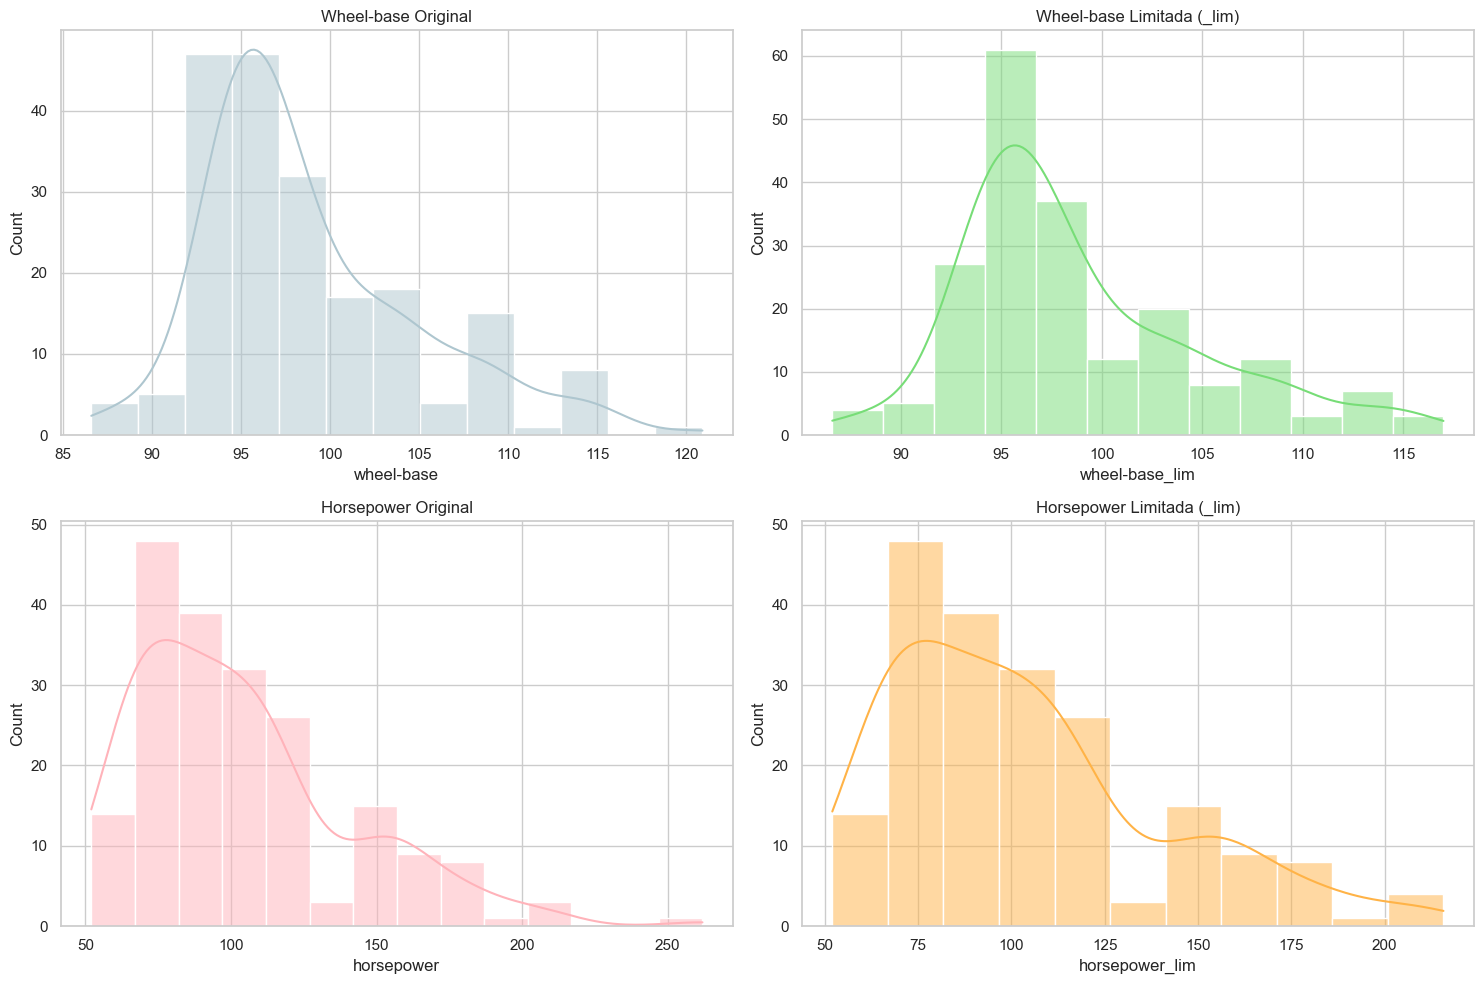

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

cor_azul_p = "#AEC6CF"  
cor_verde_p = "#77DD77" 
cor_vermelho_p = "#FFB3BA" 
cor_laranja_p = "#FFB347" 


sns.histplot(Carros3['wheel-base'], kde=True, ax=axes[0, 0], color=cor_azul_p).set_title('Wheel-base Original')
sns.histplot(Carros3['wheel-base_lim'], kde=True, ax=axes[0, 1], color=cor_verde_p).set_title('Wheel-base Limitada (_lim)')

sns.histplot(Carros3['horsepower'], kde=True, ax=axes[1, 0], color=cor_vermelho_p).set_title('Horsepower Original')
sns.histplot(Carros3['horsepower_lim'], kde=True, ax=axes[1, 1], color=cor_laranja_p).set_title('Horsepower Limitada (_lim)')

plt.tight_layout()
plt.show()

**Passo 9** - Calcular a correlação entre as variáveis do passo 7, original e a limitada, e a váriavel price. Que podemos concluir? 

In [9]:
corr_wb_orig = Carros3['wheel-base'].corr(Carros3['price'])
corr_wb_lim = Carros3['wheel-base_lim'].corr(Carros3['price'])

corr_hp_orig = Carros3['horsepower'].corr(Carros3['price'])
corr_hp_lim = Carros3['horsepower_lim'].corr(Carros3['price'])

print(f"Wheel-base Original vs Preço: {corr_wb_orig:.4f}")
print(f"Wheel-base Limitada vs Preço: {corr_wb_lim:.4f}")
print("-" * 30)
print(f"Horsepower Original vs Preço: {corr_hp_orig:.4f}")
print(f"Horsepower Limitada vs Preço: {corr_hp_lim:.4f}")


Wheel-base Original vs Preço: 0.5817
Wheel-base Limitada vs Preço: 0.5766
------------------------------
Horsepower Original vs Preço: 0.8087
Horsepower Limitada vs Preço: 0.8094


Observando esse resultado vemos que ao limitar a variável Wheel-base fez com que a correlação diminuisse, desta forma os valores extremos poderiam não ser erros, e sim dados reais que ajudavam a explicar os preços mais altos e ao limitá-los perdemos um pouco de informação relevante. 
Referente a variável Horsepower, vemos que a correlação aumentou, isso sugere que os outliers estavam "atrapalhando", e ao limitá-los, a relação com o preço ficou levemente mais linear. 

**Passo 10** - Considerando a variável quantitativa com maior número de outliers segundo os cálculos do passo 5, criar uma nova variável com base nessa, como o sufixo '_decil', que corresponde ao valor da variável quando agrupada em 10 decis. 

In [10]:
var_max_outliers = 'price'
Carros3[var_max_outliers + '_decil'] = pd.qcut(Carros3[var_max_outliers], q=10, labels=False) + 1

**Passo 11** - Considerando as variáveis do passo anterior, original e a decis, compara os seus histogramas

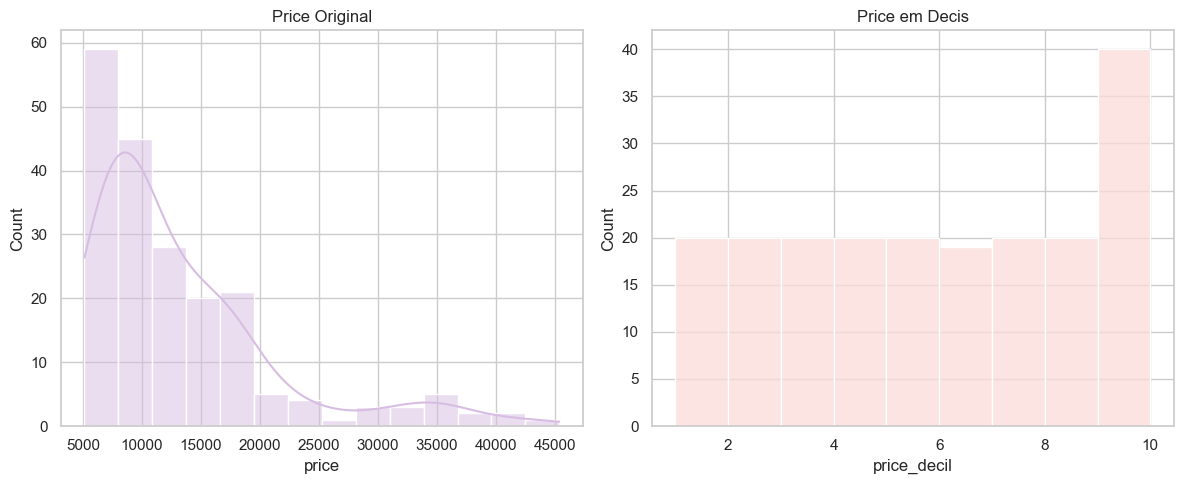

In [11]:
plt.figure(figsize=(12, 5))
cor_roxa_p = "#D7BDE2"
cor_rosa_p = "#FADBD8" 

plt.subplot(1, 2, 1)
sns.histplot(Carros3[var_max_outliers], kde=True, color=cor_roxa_p)
plt.title(f'{var_max_outliers.capitalize()} Original')

plt.subplot(1, 2, 2)
sns.histplot(Carros3[var_max_outliers + '_decil'], color=cor_rosa_p)
plt.title(f'{var_max_outliers.capitalize()} em Decis')

plt.tight_layout()
plt.show()

**Passo 12** - Calcula a correlação entre as variáveis do passo 10, original e decis, e a variável price. Que podes concluir?

In [12]:
corr_bruta = Carros3['price'].corr(Carros3['price'])
corr_decil = Carros3['price_decil'].corr(Carros3['price'])

print(f"Correlação Preço Bruto vs Preço: {corr_bruta:.4f}")
print(f"Correlação Preço em Decis vs Preço: {corr_decil:.4f}")

Correlação Preço Bruto vs Preço: 1.0000
Correlação Preço em Decis vs Preço: 0.8500


Podemos concluir que ao transformar a variável em decis, perdemos correlação, mas ganhamos uma visão mais estável da faixa de preços, desta forma deixando os dados mais balanceados para a análise.

### <span style="color: blue;"> * **Exercicio 1, PARTE 2**</span>


**Passo 1** - Criar uma nova variável numérica com base na variável num-of-doors

In [17]:
number_of_doors = {'two': 2, 'four': 4}

Carros3['numeric-num-of-doors'] = Carros3['num-of-doors'].map(number_of_doors)

print(Carros3[['num-of-doors', 'numeric-num-of-doors']].head())

  num-of-doors  numeric-num-of-doors
0         four                     4
1          two                     2
2          two                     2
3          two                     2
4         four                     4


**Passo 2** - Criar variáveis Dummy para a variável body-style

In [19]:
dummies_body_style = pd.get_dummies(Carros3['body-style'])

Carros3 = pd.concat([Carros3, dummies_body_style], axis=1)

print(dummies_body_style.head())

   convertible  hardtop  hatchback  sedan  wagon
0        False    False      False   True  False
1        False    False      False   True  False
2        False    False      False   True  False
3        False    False       True  False  False
4        False    False      False   True  False


**Passo 3** - Converter as variáveis wheel-base, lenght, width e height para centímetros sem casas decimais

In [24]:
medida_cm = ['wheel-base', 'length', 'width', 'height']

for col in medida_cm:
    
    Carros3[col + '_cm'] = (Carros3[col] * 2.54).round(0).astype(int)
    
print(Carros3[['length', 'length_cm', 'width', 'width_cm']].head())

   length  length_cm  width  width_cm
0   171.7        436   65.5       166
1   169.1        430   66.0       168
2   176.8        449   64.8       165
3   169.0        429   65.7       167
4   175.4        446   65.2       166


**Passo 4** - Converter a variável price para euros com 2 casas decimais

In [25]:
taxa_conversão = 0.92
Carros3['price_euro'] = (Carros3['price'] * taxa_conversão).round(2)

print(Carros3[['price', 'price_euro']].head())

     price  price_euro
0   9995.0      9195.4
1  10345.0      9517.4
2  16430.0     15115.6
3  11845.0     10897.4
4  12945.0     11909.4


**Passo 5** - Com base na análise dos valores da variável price, criar uma nova variável com 3 nívevis de preço: alto, médio e baixo. Explorem a distribuição da variável para melhor propror esses níveis (Justifique a escolha dos valores de corte)

In [26]:
p25 = Carros3['price'].quantile(0.25) # Limite para preço baixo
p75 = Carros3['price'].quantile(0.75) # Limite para preço alto

def categorizar_preco(p):
    if p <= p25:
        return 'baixo'
    elif p < p75:
        return 'médio'
    else:
        return 'alto'

Carros3['nivel_preco'] = Carros3['price'].apply(categorizar_preco)

print(Carros3['nivel_preco'].value_counts())

nivel_preco
médio    99
alto     50
baixo    50
Name: count, dtype: int64


Os cortes foram feitos baseados nos quartis, 1º quartil (até {p25}) e 3º quartil (acima de {p75}).

### <span style="color: blue;"> * **Exercicio 1, PARTE 3**</span>

**Passo 1** - Analisar a distribuição da variável price através de uma Boxplot. Que conclusões se podem tirar deste gráfico?

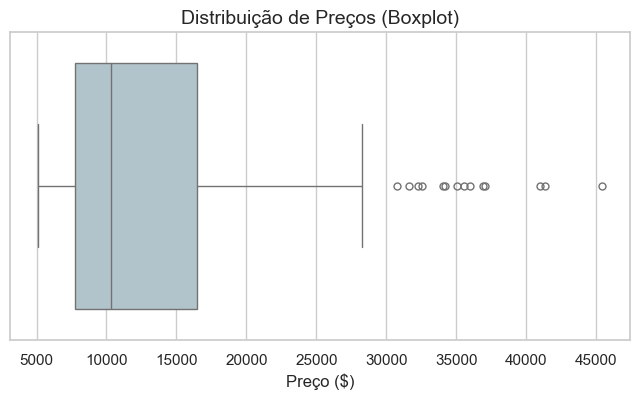

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.boxplot(x=Carros3['price'], color='#AEC6CF', fliersize=5)
plt.title('Distribuição de Preços (Boxplot)', fontsize=14)
plt.xlabel('Preço ($)')
plt.show()

O gráfico revela uma distribuição assimétrica à direita, com a maioria dos veículos custando abaixo de 16.500. A presença de múltiplos outliers acima de 30.000 indica um segmento de carros de luxo ou alto desempenho que se diferencia drasticamente da média do mercado analisado.

**Passo 2** - Escolher uma variável que seja adequado ser analisada via gráfico de barras e começar por criar uma tabela de frequências.

In [40]:
tabela_freq = Carros3['body-style'].value_counts()
print("Tabela de Frequências:")
print(tabela_freq)


Tabela de Frequências:
body-style
sedan          93
hatchback      67
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64


**Passo 3** - Criar um gráfico de barras e um Pie Chart com base na tabela de frequências criada no passo anterior

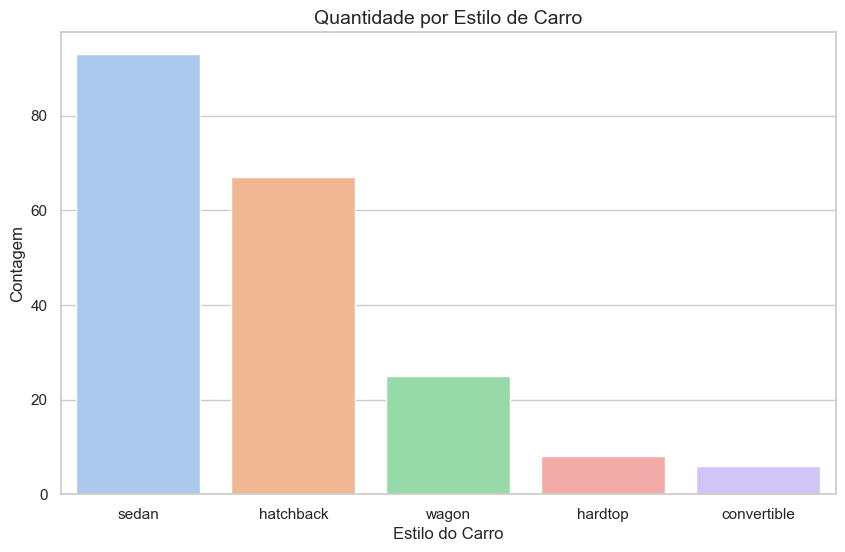

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_freq.index, 
    y=tabela_freq.values, 
    hue=tabela_freq.index, 
    palette='pastel', 
    legend=False
)

plt.title('Quantidade por Estilo de Carro', fontsize=14)
plt.xlabel('Estilo do Carro')
plt.ylabel('Contagem')
plt.show()


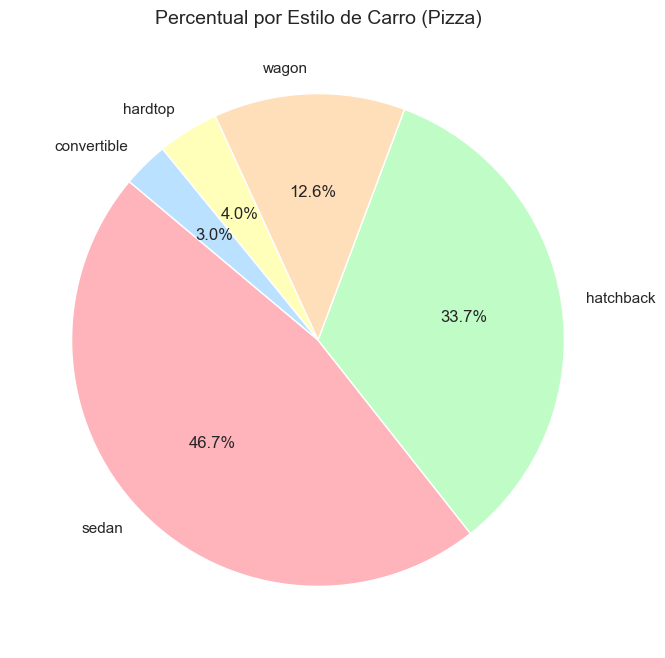

In [43]:
cores_pizza = ['#FFB3BA', '#BFFCC6', '#FFDFBA', '#FFFFBA', '#BAE1FF']

plt.figure(figsize=(8, 8))
plt.pie(tabela_freq, 
        labels=tabela_freq.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cores_pizza, 
        wedgeprops={'edgecolor': 'white'})

plt.title('Percentual por Estilo de Carro (Pizza)', fontsize=14)
plt.show()

**Passo 4** - Explorar via Scatter Plot a relação entre a variável horsepower e a variável price. Que tipo de relação parece que as variáveis apresentam?

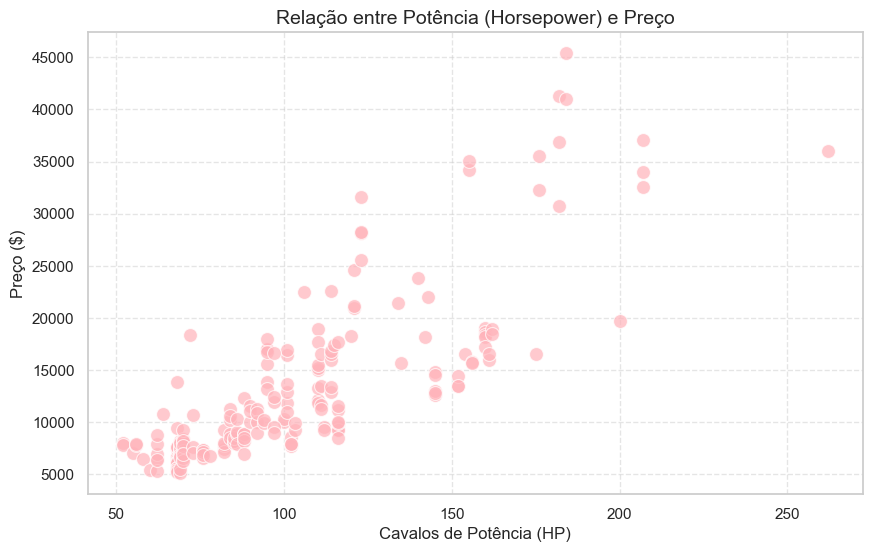

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=Carros3, x='horsepower', y='price', color='#FFB3BA', s=100, alpha=0.7)

plt.title('Relação entre Potência (Horsepower) e Preço', fontsize=14)
plt.xlabel('Cavalos de Potência (HP)')
plt.ylabel('Preço ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

O gráfico de dispersão revela uma relação linear positiva e forte. O comportamento dos dados confirma que a potência do motor é um dos principais preditores do valor do veículo, com uma concentração clara de modelos de entrada na base do gráfico e uma dispersão maior nos modelos de luxo/performance no topo direito.

**Passo 5** - Criar um Heatmap para explorar a correlaçãp entre todas as variáveis quantitativas. Que conclusões podemos tirar desta representação gráfica? 

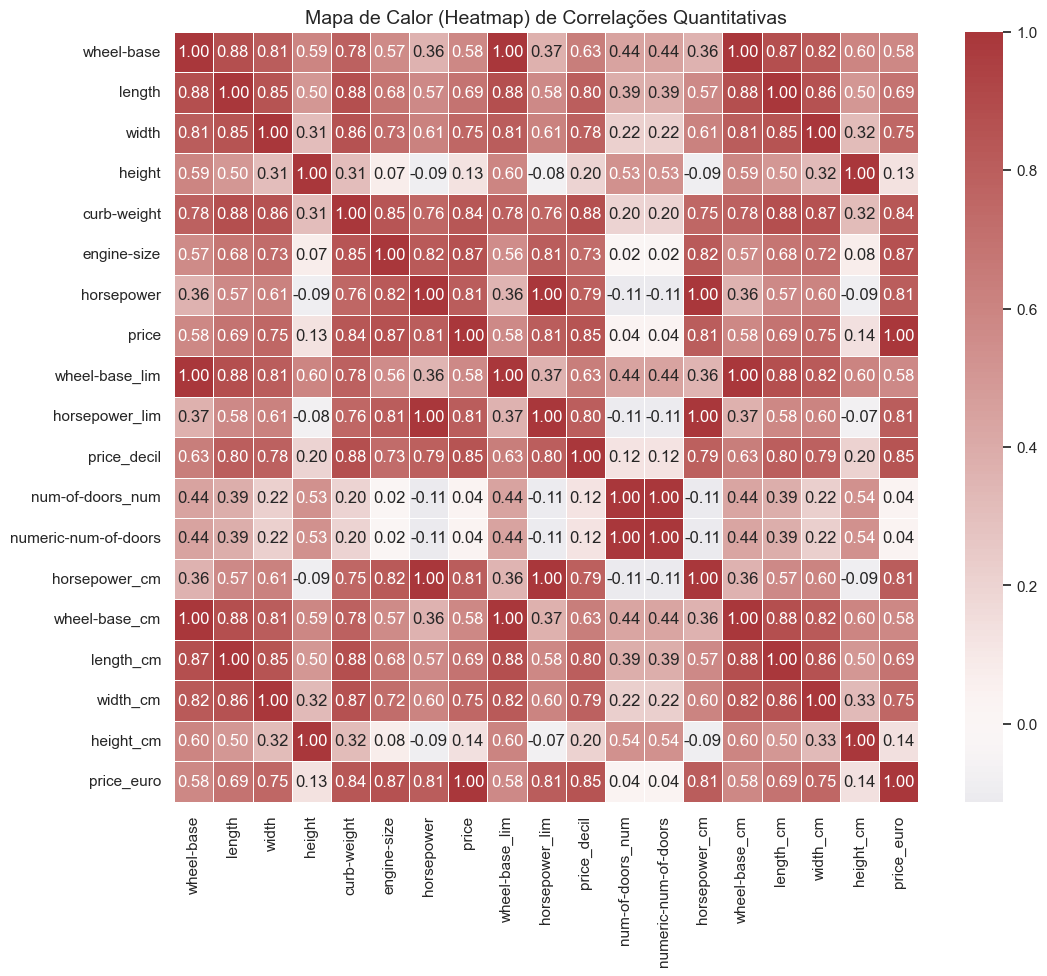

In [48]:
colunas_quantitativas = Carros3.select_dtypes(include=['float64', 'int64'])

corr_matrix = colunas_quantitativas.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', linewidths=0.5, center=0)

plt.title('Mapa de Calor (Heatmap) de Correlações Quantitativas', fontsize=14)
plt.show()

O preço dos veículos demonstra forte dependência em relação ao tamanho do motor, peso e potência, todos com coeficientes acima de 0.80. Enquanto as dimensões de largura e comprimento acompanham essa tendência de valorização, fatores como a altura do veículo e a quantidade de portas possuem mínima influência na composição do preço final neste conjunto de dados.